# Figure 1 — quality-filter patch candidates

Run top-to-bottom. This notebook scans **raw PCam** patches with the same rules as `scripts/preprocess_histopath_h5.py` (`passes_quality`) and shows **candidate tiles** for Figure 1:

1. **Low tissue** (rejected)
2. **Solid colour** (rejected)
3. **High black** (rejected)
4. **Borderline retained** (passed QC but close to a threshold)

Each panel is labelled with `split:index` and a short metric snippet. After you pick favourites, note the IDs (e.g. `train:12345`) in the **Selection** cell at the bottom and tell the agent to build the final panel figure.

## 1 — Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

_cwd = Path.cwd().resolve()
REPO = _cwd if (_cwd / "scripts" / "preprocess_histopath_h5.py").is_file() else _cwd.parent
if not (REPO / "scripts" / "preprocess_histopath_h5.py").is_file():
    REPO = Path(r"C:\GP_ECG")

sys.path.insert(0, str(REPO / "scripts"))
from preprocess_histopath_h5 import (
    HIGH_BLACK_RATIO,
    LOW_TISSUE_THRESHOLD,
    SOLID_COLOR_STD,
    passes_quality,
    tissue_pct_final,
)

DATA_DIR = REPO / "pcam_data"
OUT_DIR = REPO / "reports" / "figures" / "qc_figure1_candidates"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = {
    "train": DATA_DIR / "training" / "camelyonpatch_level_2_split_train_x.h5",
    "valid": DATA_DIR / "val" / "camelyonpatch_level_2_split_valid_x.h5",
    "test": DATA_DIR / "test" / "camelyonpatch_level_2_split_test_x.h5",
}

CHUNK = 4096
MAX_SCAN_PER_SPLIT = None  # set e.g. 50000 to scan faster during dev
N_SHOW = 12  # candidates shown per category
N_KEEP = 36  # top extremes kept per category while scanning
RNG = np.random.default_rng(42)

print("REPO:", REPO)
print("Thresholds: solid std <", SOLID_COLOR_STD, ", black >=", HIGH_BLACK_RATIO, ", tissue <", LOW_TISSUE_THRESHOLD)

REPO: C:\GP_ECG
Thresholds: solid std < 0.04 , black >= 0.5 , tissue < 0.35


## 2 — Scan splits and rank candidates

In [2]:
def patch_metrics_uint8(patch_u8: np.ndarray) -> dict:
    p01 = patch_u8.astype(np.float32) / 255.0
    gray = p01.mean(axis=2)
    passed, reason = passes_quality(p01)
    tissue = tissue_pct_final(p01)
    black = float(np.sum(p01 <= 0.1) / p01.size)
    gstd = float(np.std(gray))
    return {
        "passed": passed,
        "reason": reason,
        "tissue": tissue,
        "black": black,
        "gray_std": gstd,
    }


def borderline_score(m: dict) -> float:
    """Higher = closer to failing while still passed."""
    if not m["passed"]:
        return -1.0
    d_tissue = m["tissue"] - LOW_TISSUE_THRESHOLD
    d_black = HIGH_BLACK_RATIO - m["black"]
    d_std = m["gray_std"] - SOLID_COLOR_STD
    # small positive margins => more borderline
    margins = [d_tissue, d_black, d_std]
    pos = [x for x in margins if x >= 0]
    if not pos:
        return -1.0
    return float(min(pos))


def update_pool(pool: list, item: dict, key_fn, n_keep: int, reverse: bool):
    pool.append(item)
    pool.sort(key=key_fn, reverse=reverse)
    del pool[n_keep:]


pools = {
    "low_tissue": [],
    "solid_color": [],
    "high_black": [],
    "borderline": [],
}

for split, h5_path in SPLITS.items():
    if not h5_path.is_file():
        print("SKIP (missing):", h5_path)
        continue
    with h5py.File(h5_path, "r") as f:
        ds = f["x"]
        n_total = ds.shape[0]
        n_scan = n_total if MAX_SCAN_PER_SPLIT is None else min(n_total, MAX_SCAN_PER_SPLIT)
        print(f"Scanning {split}: {n_scan:,} / {n_total:,} patches ...")
        for start in range(0, n_scan, CHUNK):
            block = ds[start : start + CHUNK]
            for j, patch in enumerate(block):
                idx = start + j
                m = patch_metrics_uint8(patch)
                rec = {"split": split, "index": int(idx), "metrics": m}
                if m["reason"] == "low_tissue":
                    update_pool(pools["low_tissue"], rec, lambda r: r["metrics"]["tissue"], N_KEEP, reverse=False)
                elif m["reason"] == "solid_color":
                    update_pool(pools["solid_color"], rec, lambda r: r["metrics"]["gray_std"], N_KEEP, reverse=False)
                elif m["reason"] == "high_black":
                    update_pool(pools["high_black"], rec, lambda r: r["metrics"]["black"], N_KEEP, reverse=True)
                bs = borderline_score(m)
                if bs >= 0:
                    rec_b = {**rec, "borderline_margin": bs}
                    update_pool(pools["borderline"], rec_b, lambda r: r["borderline_margin"], N_KEEP, reverse=False)

for k, v in pools.items():
    print(f"  {k}: {len(v)} kept")

meta_path = OUT_DIR / "candidates_ranked.json"
with meta_path.open("w", encoding="utf-8") as f:
    json.dump({k: [{"split": r["split"], "index": r["index"], "metrics": r["metrics"], **({"borderline_margin": r["borderline_margin"]} if "borderline_margin" in r else {})} for r in v] for k, v in pools.items()}, f, indent=2)
print("Saved", meta_path)

Scanning train: 262,144 / 262,144 patches ...
Scanning valid: 32,768 / 32,768 patches ...
Scanning test: 32,768 / 32,768 patches ...
  low_tissue: 36 kept
  solid_color: 36 kept
  high_black: 13 kept
  borderline: 36 kept
Saved C:\GP_ECG\reports\figures\qc_figure1_candidates\candidates_ranked.json


## 3 — Show candidate grids (pick from labels)

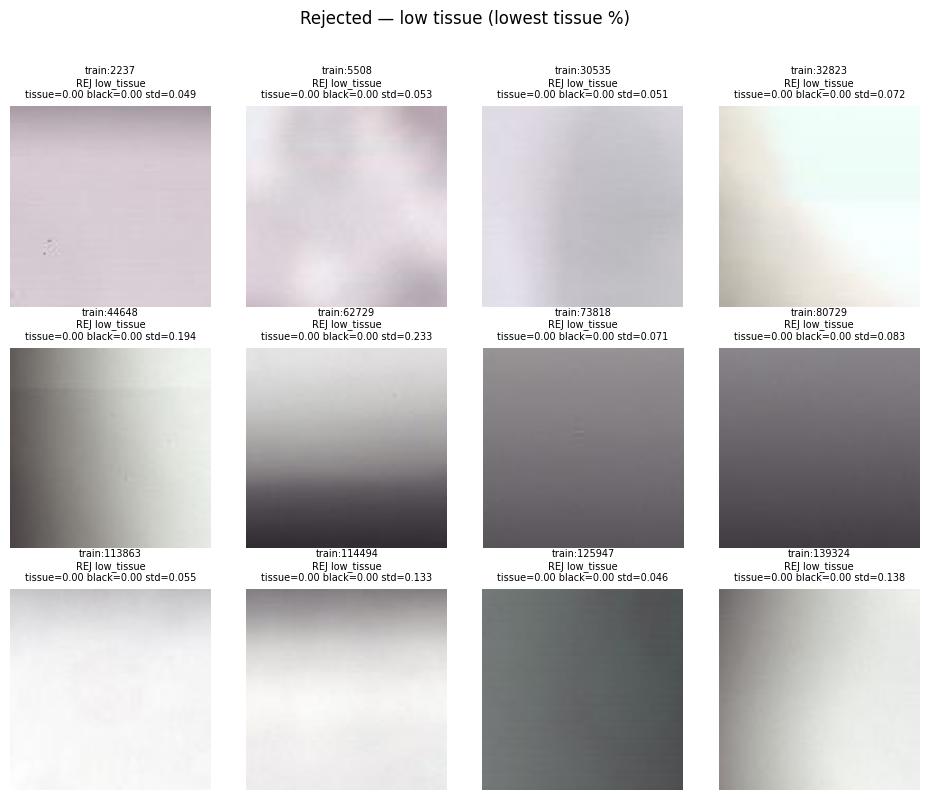

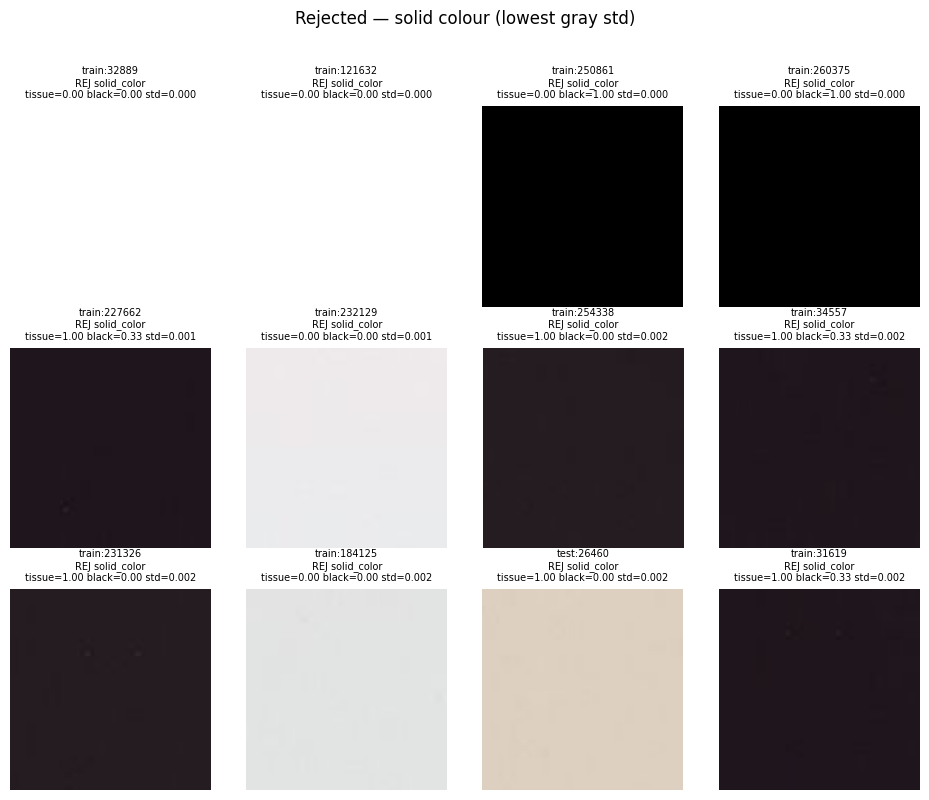

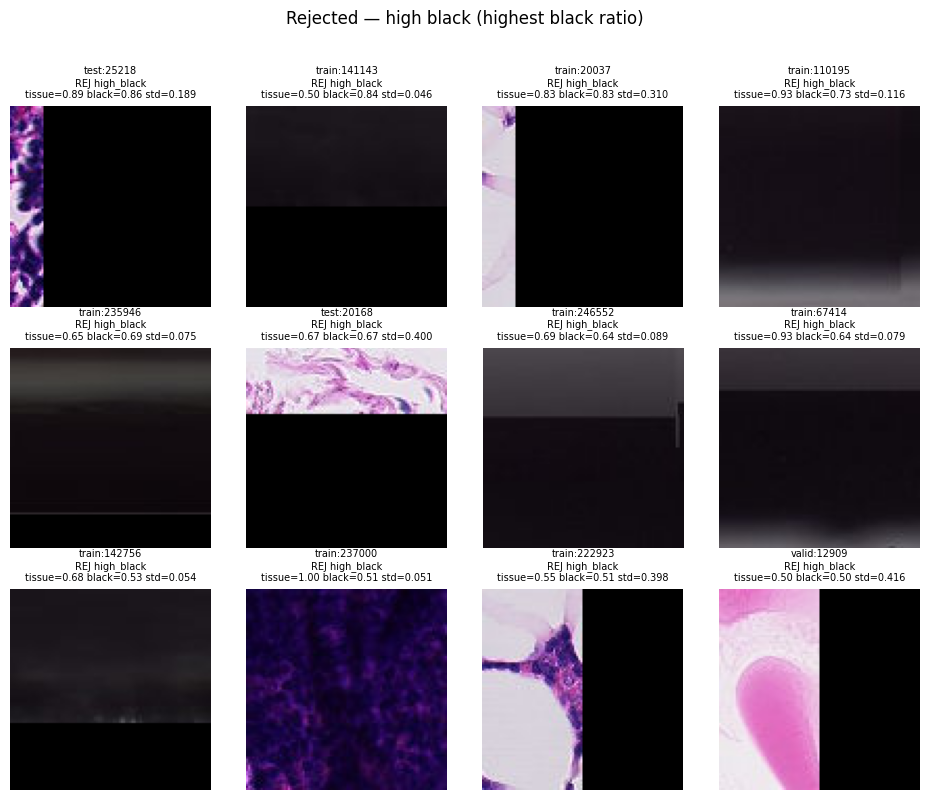

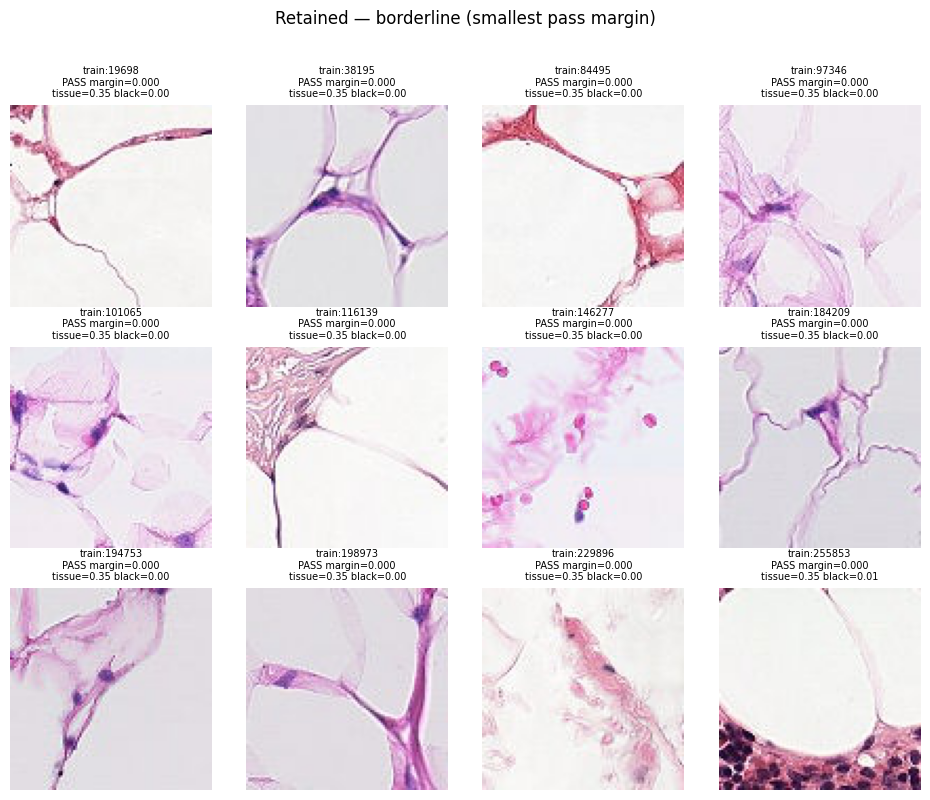

In [3]:
def load_patch(split: str, index: int) -> np.ndarray:
    path = SPLITS[split]
    with h5py.File(path, "r") as f:
        return f["x"][index]


def caption_for(rec: dict) -> str:
    m = rec["metrics"]
    sid = f"{rec['split']}:{rec['index']}"
    if rec.get("borderline_margin") is not None:
        return f"{sid}\nPASS margin={rec['borderline_margin']:.3f}\ntissue={m['tissue']:.2f} black={m['black']:.2f}"
    return f"{sid}\nREJ {m['reason']}\ntissue={m['tissue']:.2f} black={m['black']:.2f} std={m['gray_std']:.3f}"


def show_grid(pool: list, title: str, n: int = N_SHOW, ncol: int = 4):
    picks = pool[:n]
    if not picks:
        print("No candidates for", title)
        return
    nrow = int(np.ceil(len(picks) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.4 * ncol, 2.6 * nrow))
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, rec in zip(axes.ravel(), picks):
        patch = load_patch(rec["split"], rec["index"])
        ax.imshow(patch)
        ax.set_title(caption_for(rec), fontsize=7)
    fig.suptitle(title, fontsize=12, y=1.02)
    fig.tight_layout()
    safe = title.lower().replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(OUT_DIR / f"candidates_{safe}.png", dpi=150, bbox_inches="tight")
    plt.show()


show_grid(pools["low_tissue"], "Rejected — low tissue (lowest tissue %)")
show_grid(pools["solid_color"], "Rejected — solid colour (lowest gray std)")
show_grid(pools["high_black"], "Rejected — high black (highest black ratio)")
show_grid(pools["borderline"], "Retained — borderline (smallest pass margin)")

## 4 — Your selections (fill in, then share with agent)

Copy one `split:index` per panel row you want in the final figure (or more if you want alternatives).

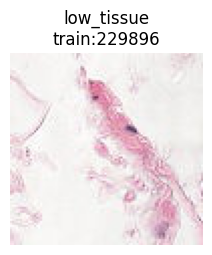

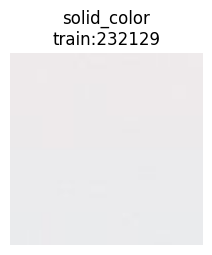

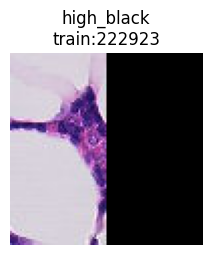

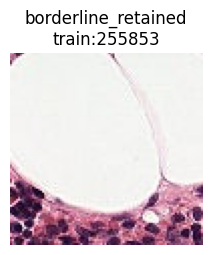

In [5]:
SELECTIONS = {
    "low_tissue": "train:229896",      # e.g. train:1042
    "solid_color": "train:232129",
    "high_black": "train:222923",
    "borderline_retained": "train:255853",
}

# Preview your picks (run after filling IDs)
for label, sid in SELECTIONS.items():
    if ":" not in sid or "?" in sid:
        print(label, "— not set")
        continue
    split, idx_s = sid.split(":", 1)
    patch = load_patch(split, int(idx_s))
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(patch)
    plt.title(f"{label}\n{sid}")
    plt.axis("off")
    plt.show()

## 5 — Build Figure 1 panel (for Results)

Run after **SELECTIONS** is filled. Writes `reports/figures/figure1_quality_filter_panels.png` and `.pdf` (300 dpi).

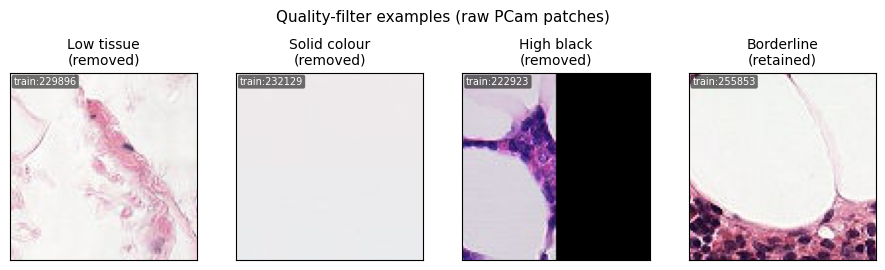

Saved: C:\GP_ECG\reports\figures\figure1_quality_filter_panels.png
Saved: C:\GP_ECG\reports\figures\figure1_quality_filter_panels.pdf


In [6]:
PANEL_ORDER = [
    ("low_tissue", "Low tissue\n(removed)"),
    ("solid_color", "Solid colour\n(removed)"),
    ("high_black", "High black\n(removed)"),
    ("borderline_retained", "Borderline\n(retained)"),
]

FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_PNG = FIG_DIR / "figure1_quality_filter_panels.png"
FIG_PDF = FIG_DIR / "figure1_quality_filter_panels.pdf"


def parse_selection(sid: str) -> tuple[str, int]:
    if ":" not in sid or "?" in sid:
        raise ValueError(f"Invalid selection id: {sid!r} — fill SELECTIONS in the cell above.")
    split, idx_s = sid.split(":", 1)
    if split not in SPLITS:
        raise ValueError(f"Unknown split {split!r}; expected one of {list(SPLITS)}")
    return split, int(idx_s)


fig, axes = plt.subplots(1, 4, figsize=(9.2, 2.6))
for ax, (key, title) in zip(axes, PANEL_ORDER):
    if key not in SELECTIONS:
        raise KeyError(f"SELECTIONS missing key {key!r}")
    split, index = parse_selection(SELECTIONS[key])
    patch = load_patch(split, index)
    ax.imshow(patch)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    ax.text(
        0.02,
        0.98,
        f"{split}:{index}",
        transform=ax.transAxes,
        fontsize=7,
        va="top",
        ha="left",
        color="white",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.55, linewidth=0),
    )

fig.suptitle("Quality-filter examples (raw PCam patches)", fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIG_PNG, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(FIG_PDF, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", FIG_PNG)
print("Saved:", FIG_PDF)